In [1]:
import os
import sys

# Get the current directory (Graphs folder)
current_dir = os.getcwd()
# Get the parent directory
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
# Add the parent directory to the sys.path
sys.path.append(parent_dir)

import json
from graphs import *
import matplotlib.pyplot as plt

import seaborn as sns
import pandas as pd

In [2]:
# Define a function to calculate min and max for error bars
def min_max_error(x):
    return (x.min(), x.max())

In [3]:
def read_sim_results(filename):
    file_path = os.path.join(parent_dir, filename)
    with open(file_path, 'r') as f:
        sim_data = json.load(f)
    qaoa_cost = sim_data["QAOA_Cost"]
    rqaoa_cost = sim_data["RQAOA_Cost"]
    rqaoa_20_cost = sim_data["RQAOA_20_Cost"]
    sdp_cost = sim_data["SDP_Cost"]
    
    return qaoa_cost, rqaoa_cost, rqaoa_20_cost, sdp_cost

In [4]:
size = 256
ps = [0.1, 0.3, 0.5, 0.7, 0.9]

qaoa_er_costs = {p:[] for p in ps}
rqaoa_er_costs = {p:[] for p in ps}
rqaoa20_er_costs = {p:[] for p in ps}
sdp_er_costs = {p:[] for p in ps}

for p in ps:
    for i in range(1, 21):
        filename = f"simulation_data/er_{size}_{p}_{i}.json"
        file_path = os.path.join(parent_dir, filename)
        bfilename = f"benchmark_data/er_{size}_{p}_{i}.gz"
        bfile_path = os.path.join(parent_dir, bfilename)
        _, gurobi_cost, _, _ = read_graph_from_file(bfile_path)
        qaoa_cost, rqaoa_cost, rqaoa_20_cost, sdp_cost = read_sim_results(file_path)
        qaoa_er_costs[p].append(qaoa_cost/gurobi_cost)
        rqaoa_er_costs[p].append(rqaoa_cost/gurobi_cost)
        rqaoa20_er_costs[p].append(rqaoa_20_cost/gurobi_cost)

        sdp_ar = [scost/gurobi_cost for scost in sdp_cost]
        sdp_er_costs[p].append(np.mean(sdp_ar))



In [5]:
data = []

for p in ps:   
    for cost in qaoa_er_costs[p]:
        data.append({'p': p, 'Approximation Ratio': cost, 'Algorithm': 'QAOA'})
    for cost in rqaoa20_er_costs[p]:
        data.append({'p': p, 'Approximation Ratio': cost, 'Algorithm': 'RQAOA'})
    for cost in sdp_er_costs[p]:
        data.append({'p': p, 'Approximation Ratio': cost, 'Algorithm': 'SDP'})
    for cost in rqaoa_er_costs[p]:
        data.append({'p': p, 'Approximation Ratio': cost, 'Algorithm': 'RQAOA*'})  

# Convert to DataFrame for seaborn
df = pd.DataFrame(data)

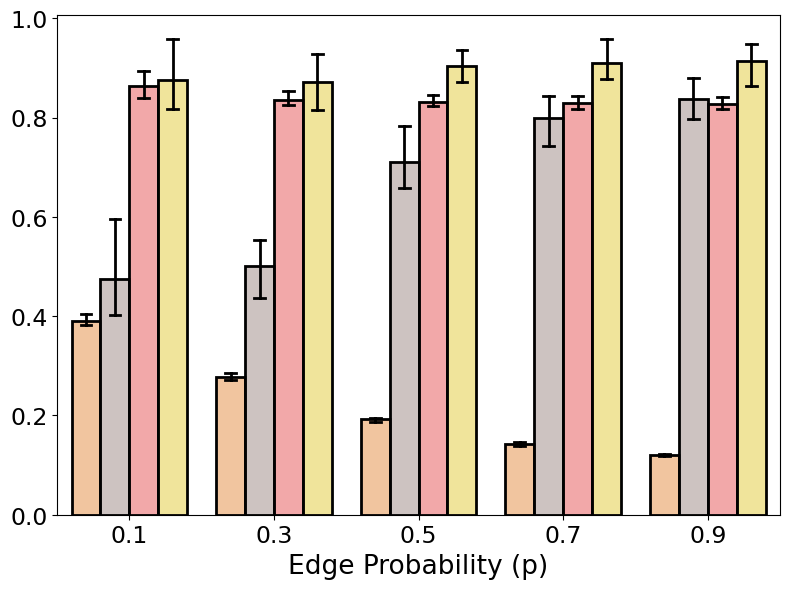

In [8]:
# Define custom color palette
palette = ['#FF9D48', '#B19994', '#ff595e', '#fee440']
algorithm_order = ['QAOA', 'RQAOA', 'SDP', 'RQAOA*'] #['QAOA', 'Local', 'SDP', 'RQAOA*', 'RLocal']

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Create barplot
sns.barplot(
    data=df,
    x="p", y="Approximation Ratio", hue="Algorithm",
    errorbar=min_max_error, palette=palette, edgecolor='black', linewidth=2, hue_order=algorithm_order,
    capsize=0.3, err_kws={'linewidth': 2, 'color': 'black'}, width=0.8, ax=ax, legend=False
)

# Set transparency only for bar colors, not edgecolors
for bar in ax.patches:
    facecolor = bar.get_facecolor()
    bar.set_facecolor((*facecolor[:3], 0.6))  # Apply alpha only to facecolor

# Customize the plot
ax.set_ylabel('', fontsize=16)
ax.set_xlabel('Edge Probability (p)', fontsize=19)
#ax.legend(loc='lower left', fontsize=15, ncol=2)

# Set tick parameters
ax.tick_params(axis='x', labelsize=17)
ax.tick_params(axis='y', labelsize=17)

plt.tight_layout()
plt.savefig('rqaoa_comp_256.pdf', bbox_inches='tight')
plt.show()

In [7]:
def read_sim_results(filename):
    file_path = os.path.join(parent_dir, filename)
    with open(file_path, 'r') as f:
        sim_data = json.load(f)
    qaoa_cost = sim_data["QAOA_Cost"]
    rqaoa_cost = sim_data["RQAOAF_Cost"]
    rqaoa_20_cost = sim_data["RQAOAF_20_Cost"]
    sdp_cost = sim_data["SDP_Cost"]
    
    return qaoa_cost, rqaoa_cost, rqaoa_20_cost, sdp_cost

size = 256
ps = [0.1, 0.3, 0.5, 0.7, 0.9]

qaoa_er_costs = {p:[] for p in ps}
rqaoa_er_costs = {p:[] for p in ps}
rqaoa20_er_costs = {p:[] for p in ps}
sdp_er_costs = {p:[] for p in ps}

for p in ps:
    for i in range(1, 21):
        filename = f"simulation_data/erf_{size}_{p}_{i}.json"
        file_path = os.path.join(parent_dir, filename)
        bfilename = f"benchmark_data/erf_{size}_{p}_{i}.gz"
        bfile_path = os.path.join(parent_dir, bfilename)
        _, gurobi_cost, _, _ = read_graph_from_file(bfile_path)
        qaoa_cost, rqaoa_cost, rqaoa_20_cost, sdp_cost = read_sim_results(file_path)
        qaoa_er_costs[p].append(qaoa_cost/gurobi_cost)
        rqaoa_er_costs[p].append(rqaoa_cost/gurobi_cost)
        rqaoa20_er_costs[p].append(rqaoa_20_cost/gurobi_cost)
        sdp_ar = [scost/gurobi_cost for scost in sdp_cost]
        sdp_er_costs[p].append(np.mean(sdp_ar))

data = []

for p in ps:   
    for cost in qaoa_er_costs[p]:
        data.append({'p': p, 'Approximation Ratio': cost, 'Algorithm': 'QAOA'})
    for cost in rqaoa20_er_costs[p]:
        data.append({'p': p, 'Approximation Ratio': cost, 'Algorithm': 'Iter-QAOA'})
    for cost in sdp_er_costs[p]:
        data.append({'p': p, 'Approximation Ratio': cost, 'Algorithm': 'SDP'})
    for cost in rqaoa_er_costs[p]:
        data.append({'p': p, 'Approximation Ratio': cost, 'Algorithm': 'Iter-QAOA*'})  

# Convert to DataFrame for seaborn
df = pd.DataFrame(data)


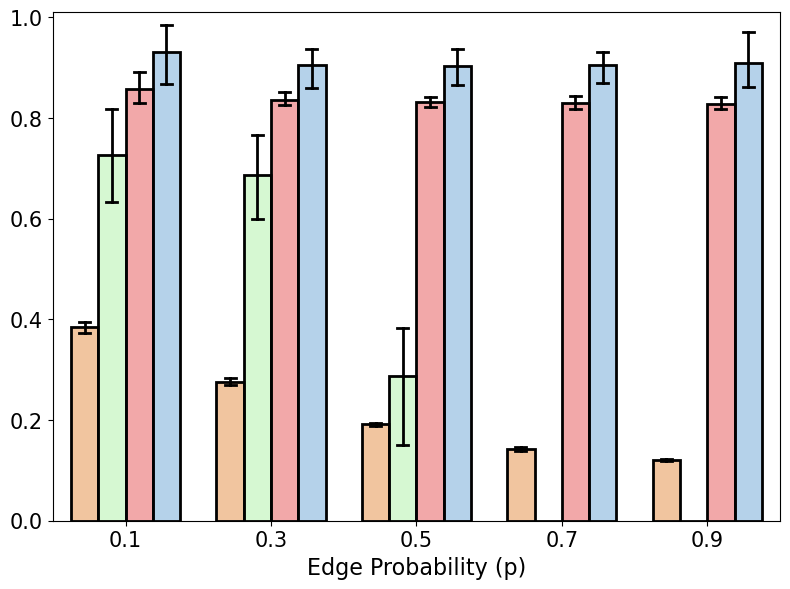

In [8]:
# Define custom color palette
palette = ['#FF9D48', '#B2FFA9', '#ff595e', '#77B6EA'] #68B0AB #C06E52
algorithm_order =  ['QAOA', 'Iter-QAOA', 'SDP', 'Iter-QAOA*'] #['QAOA', 'RQAOA', 'SDP', 'RQAOA*'] ['QAOA', 'Local', 'SDP', 'RQAOA*', 'RLocal']

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Create barplot
sns.barplot(
    data=df,
    x="p", y="Approximation Ratio", hue="Algorithm",
    errorbar=min_max_error, palette=palette, edgecolor='black', linewidth=2, hue_order=algorithm_order,
    capsize=0.3, err_kws={'linewidth': 2, 'color': 'black'}, width=0.75, ax=ax, legend=False
)

# Set transparency only for bar colors, not edgecolors
for bar in ax.patches:
    facecolor = bar.get_facecolor()
    bar.set_facecolor((*facecolor[:3], 0.6))  # Apply alpha only to facecolor

# Customize the plot
ax.set_ylabel('', fontsize=16)
ax.set_xlabel('Edge Probability (p)', fontsize=16)
#ax.legend(loc='lower left', fontsize=15, ncol=2)

# Set tick parameters
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.set_ylim(0, 1.01)
plt.tight_layout()
plt.savefig('rqaoa_comp_256_fields.pdf', bbox_inches='tight')
plt.show()